# 07 · Error Analysis

Notebook 05 reported *how much* the model gets wrong (recall by category, confusion
matrix counts). This notebook asks *what kind* of wrong — do false negatives share a
profile, are they borderline misses or confidently-wrong blind spots, and which features
actually drive the mistakes. Standard error-analysis practice for tabular models: compare
feature distributions across confusion-matrix outcomes, separate near-miss errors
(score close to the threshold) from confidently-wrong ones (the model is sure, and wrong),
and use SHAP to check whether errors share a common *reason*, not just a common outcome.

**Uses the validation set, not test.** Error analysis is iterative, exploratory work —
the kind that leads to "try adding this feature" or "look closer at this segment"
follow-ups. Doing that against the test set would burn the one held-out, unbiased read
this project has left; notebook 05 already spent test on the final reported numbers.

In [1]:
%matplotlib inline
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import xgboost as xgb

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

with open("../data/processed/feature_columns.json") as f:
    cfg = json.load(f)
FEATURES, LABEL = cfg["features"], cfg["label"]

val = pd.read_parquet("../data/processed/val.parquet").reset_index(drop=True)
X_val = val[FEATURES]

model = xgb.XGBClassifier()
model.load_model("../models/fraud_xgboost.json")

with open("../models/threshold.json") as f:
    threshold_cfg = json.load(f)
GLOBAL_THRESHOLD = threshold_cfg["decision_threshold"]
CATEGORY_THRESHOLDS = threshold_cfg.get("category_thresholds", {})

val["proba"] = model.predict_proba(X_val)[:, 1]
val["threshold"] = val["category"].map(CATEGORY_THRESHOLDS).fillna(GLOBAL_THRESHOLD)
val["pred"] = (val["proba"] >= val["threshold"]).astype(int)
val["margin"] = val["proba"] - val["threshold"]  # >0 means flagged; magnitude = confidence

print(f"val: {val.shape}, fraud rate={val[LABEL].mean():.4%}")
print(f"using the same deployed model + category-aware thresholds as src/api/")

val: (157287, 31), fraud rate=0.4476%
using the same deployed model + category-aware thresholds as src/api/


## Confusion matrix outcomes on validation

In [2]:
def outcome(row):
    if row[LABEL] == 1 and row.pred == 1:
        return "TP"
    if row[LABEL] == 1 and row.pred == 0:
        return "FN"
    if row[LABEL] == 0 and row.pred == 1:
        return "FP"
    return "TN"

val["outcome"] = val.apply(outcome, axis=1)
counts = val["outcome"].value_counts()
print(counts)
print(f"\nrecall (TP / (TP+FN)): {counts['TP'] / (counts['TP'] + counts['FN']):.4f}")
print(f"specificity (TN / (TN+FP)): {counts['TN'] / (counts['TN'] + counts['FP']):.4f}")

fn = val[val.outcome == "FN"].copy()
fp = val[val.outcome == "FP"].copy()
tp = val[val.outcome == "TP"].copy()
tn = val[val.outcome == "TN"].copy()

outcome
TN    154353
FP      2230
TP       651
FN        53
Name: count, dtype: int64

recall (TP / (TP+FN)): 0.9247
specificity (TN / (TN+FP)): 0.9858


## Near-miss vs. confidently-wrong

Distance from the (category-specific) threshold tells a different story than the raw
error count. A false negative sitting just under the cutoff is a calibration nuance; a
false negative the model scored near 0 is a genuine blind spot no threshold tweak fixes.

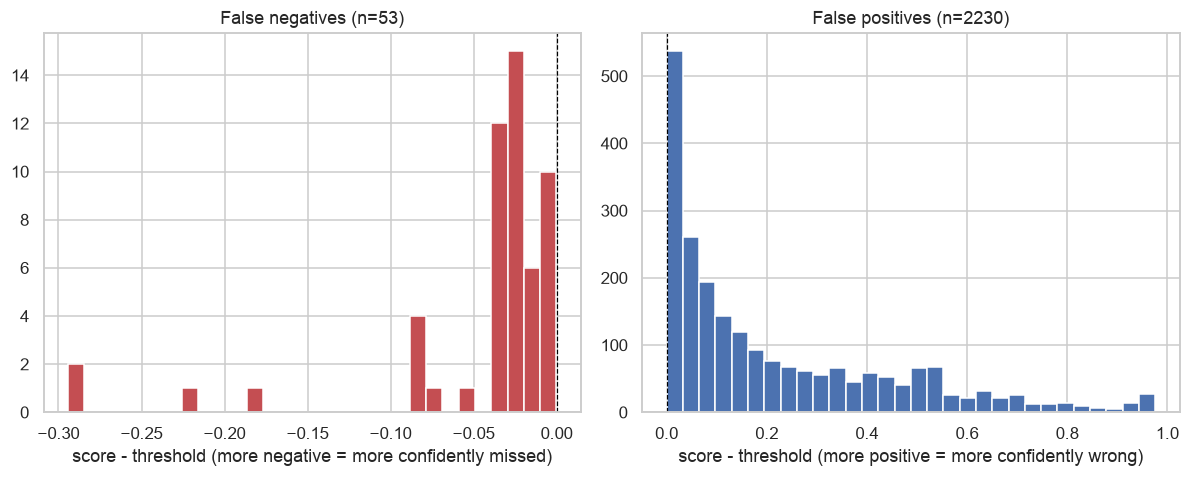

FN within 0.05 of threshold (near-miss, calibration-fixable): 43 (81.1%)
FN scored 0.20+ below threshold (confident blind spot): 3 (5.7%)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].hist(fn["margin"], bins=30, color="#C44E52")
axes[0].axvline(0, color="black", linestyle="--", linewidth=0.8)
axes[0].set_xlabel("score - threshold (more negative = more confidently missed)")
axes[0].set_title(f"False negatives (n={len(fn)})")

axes[1].hist(fp["margin"], bins=30, color="#4C72B0")
axes[1].axvline(0, color="black", linestyle="--", linewidth=0.8)
axes[1].set_xlabel("score - threshold (more positive = more confidently wrong)")
axes[1].set_title(f"False positives (n={len(fp)})")
plt.tight_layout()
plt.show()

near_miss_fn = (fn["margin"] > -0.05).sum()
confident_fn = (fn["margin"] <= -0.20).sum()
print(f"FN within 0.05 of threshold (near-miss, calibration-fixable): {near_miss_fn} "
      f"({near_miss_fn / len(fn):.1%})")
print(f"FN scored 0.20+ below threshold (confident blind spot): {confident_fn} "
      f"({confident_fn / len(fn):.1%})")

## Feature distributions: false negatives vs. caught fraud

If false negatives systematically differ from correctly-caught fraud on a feature, that
feature is (or should be) doing the separating work — and its distribution shows where the
model's boundary is missing them.

In [4]:
compare_features = [
    "amount", "amount_zscore_user", "distance_from_home_km", "category_fraud_rate_prior",
    "merchant_fraud_rate_prior", "is_new_category_for_user", "card_tenure_days",
    "time_since_prev_txn_sec",
]

summary = pd.DataFrame({
    "FN (missed fraud)": fn[compare_features].median(),
    "TP (caught fraud)": tp[compare_features].median(),
}).round(3)
summary["FN / TP ratio"] = (summary["FN (missed fraud)"] / summary["TP (caught fraud)"].replace(0, np.nan)).round(2)
summary

,FN (missed fraud),TP (caught fraud),FN / TP ratio
amount,21.050,671.930,0.03
amount_zscore_user,-0.200,3.052,-0.07
distance_from_home_km,75.280,77.483,0.97
category_fraud_rate_prior,0.002,0.014,0.14
merchant_fraud_rate_prior,0.002,0.012,0.17
is_new_category_for_user,0.000,0.000,NaN
card_tenure_days,340.000,335.000,1.01
time_since_prev_txn_sec,17580.000,4200.000,4.19


/var/folders/82/g56w2bw94xq30h2kr2g3npm40000gn/T/ipykernel_59002/2520329796.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="group", y=feat, ax=ax, palette={"FN": "#C44E52", "TP": "#55A868"},
/var/folders/82/g56w2bw94xq30h2kr2g3npm40000gn/T/ipykernel_59002/2520329796.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="group", y=feat, ax=ax, palette={"FN": "#C44E52", "TP": "#55A868"},
/var/folders/82/g56w2bw94xq30h2kr2g3npm40000gn/T/ipykernel_59002/2520329796.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(d

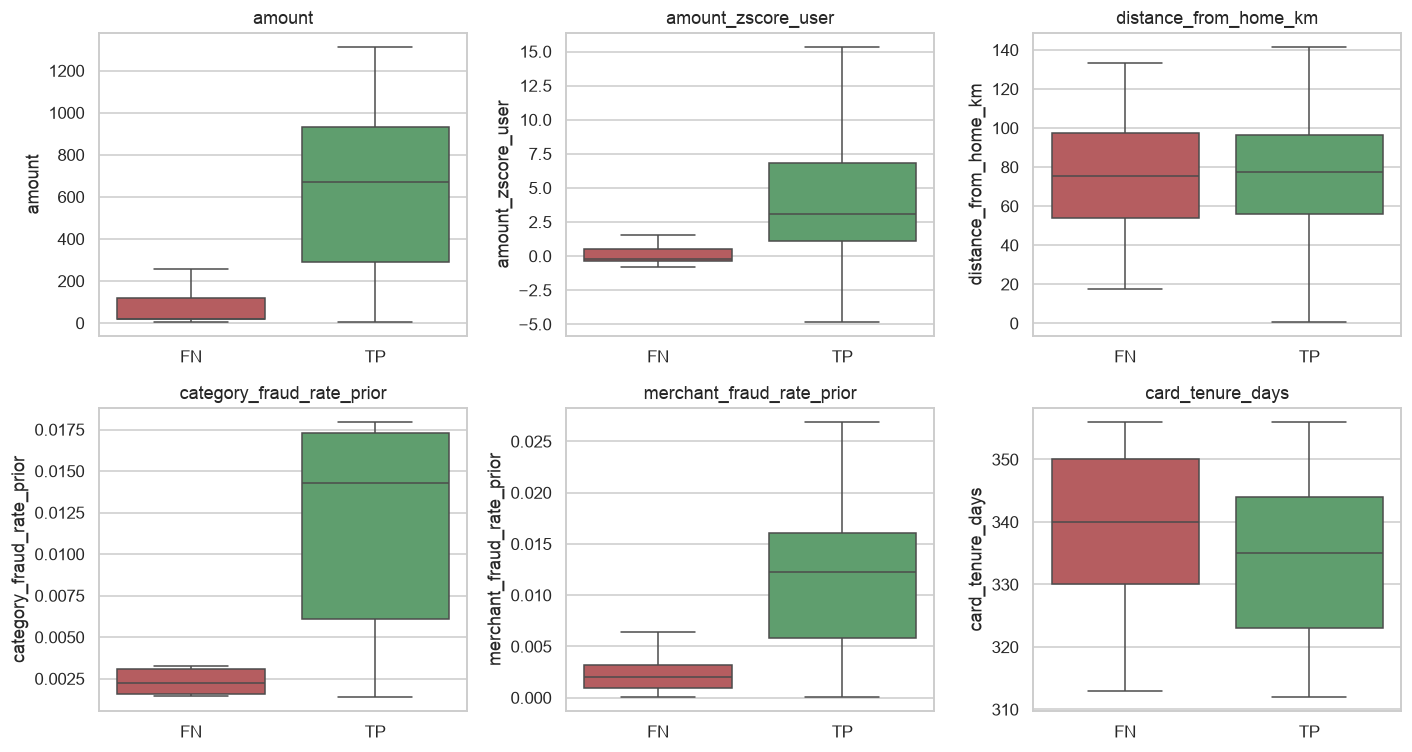

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
plot_features = ["amount", "amount_zscore_user", "distance_from_home_km",
                  "category_fraud_rate_prior", "merchant_fraud_rate_prior", "card_tenure_days"]
for ax, feat in zip(axes.flat, plot_features):
    data = pd.concat([
        fn[[feat]].assign(group="FN"),
        tp[[feat]].assign(group="TP"),
    ])
    sns.boxplot(data=data, x="group", y=feat, ax=ax, palette={"FN": "#C44E52", "TP": "#55A868"},
                showfliers=False)
    ax.set_title(feat)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

## Feature distributions: false positives vs. correctly-cleared legit transactions

The other side of the cost: which legitimate transactions look suspicious to the model,
and why.

In [6]:
summary_fp = pd.DataFrame({
    "FP (wrongly flagged)": fp[compare_features].median(),
    "TN (correctly cleared)": tn[compare_features].median(),
}).round(3)
summary_fp["FP / TN ratio"] = (summary_fp["FP (wrongly flagged)"] / summary_fp["TN (correctly cleared)"].replace(0, np.nan)).round(2)
summary_fp

,FP (wrongly flagged),TN (correctly cleared),FP / TN ratio
amount,45.790,47.270,0.97
amount_zscore_user,-0.157,-0.183,0.86
distance_from_home_km,78.042,78.222,1.00
category_fraud_rate_prior,0.003,0.003,1.00
merchant_fraud_rate_prior,0.004,0.004,1.00
is_new_category_for_user,0.000,0.000,NaN
card_tenure_days,341.000,340.000,1.00
time_since_prev_txn_sec,3780.000,10560.000,0.36


## Where errors concentrate: category and distance-from-home

Same slicing lens as notebook 05's recall-by-category, but from the count-of-errors side
rather than the recall-rate side — a category can have decent recall and still contribute
the most absolute missed-fraud dollars if it has high transaction volume.

In [7]:
fn_by_category = fn.groupby("category").agg(
    n_missed=("amount", "size"), amount_missed=("amount", "sum")
).sort_values("amount_missed", ascending=False)
print("False negatives by category (sorted by $ missed):")
print(fn_by_category)

fp_by_category = fp.groupby("category").agg(
    n_flagged=("amount", "size")
).sort_values("n_flagged", ascending=False)
print("\nFalse positives by category (sorted by count -- this is customer friction):")
print(fp_by_category)

False negatives by category (sorted by $ missed):
                n_missed  amount_missed
category                               
shopping_pos           4        3554.90
misc_net               2        1566.54
entertainment          2        1080.87
misc_pos               5        1055.77
food_dining            7         810.29
home                   2         543.71
personal_care          7         193.84
health_fitness         9         172.03
kids_pets              8         134.00
travel                 4          41.76
grocery_net            3          33.41

False positives by category (sorted by count -- this is customer friction):
                n_flagged
category                 
shopping_pos          353
misc_pos              280
shopping_net          228
entertainment         208
kids_pets             191
misc_net              184
travel                178
personal_care         173
food_dining           143
home                  109
health_fitness         75
grocery_net    

## SHAP: what's systematically different about false negatives?

Rather than explaining one example at a time (notebook 05 already does that), this
compares **mean SHAP value per feature** between false negatives and true positives — if a
feature pushes fraud predictions up for caught fraud but not for missed fraud, that
feature is where the false negatives are "hiding."

In [8]:
explainer = shap.TreeExplainer(model)

fraud_val = val[val[LABEL] == 1].copy()
shap_values_fraud = explainer(fraud_val[FEATURES])
fraud_val = fraud_val.reset_index(drop=True)

shap_df = pd.DataFrame(shap_values_fraud.values, columns=FEATURES)
shap_df["outcome"] = fraud_val["outcome"].values

shap_by_outcome = shap_df.groupby("outcome")[FEATURES].mean().T
shap_by_outcome["gap (TP - FN)"] = shap_by_outcome["TP"] - shap_by_outcome["FN"]
shap_by_outcome.sort_values("gap (TP - FN)", ascending=False).head(10)

outcome,FN,TP,gap (TP - FN)
amount,0.187079,5.500098,5.313019
card_tenure_days,-1.572961,-0.735355,0.837606
hour_cos,0.009867,0.839799,0.829933
hour_similarity_to_user,-0.525457,0.062141,0.587598
hour_sin,-0.390999,0.153004,0.544004
time_since_prev_txn_sec,-0.081326,0.217646,0.298973
merchant_fraud_rate_prior,-0.253940,0.008525,0.262465
amount_zscore_user,-0.484689,-0.231480,0.253209
category_fraud_rate_prior,-0.940194,-0.780927,0.159266
dow_sin,-0.072587,-0.040995,0.031592


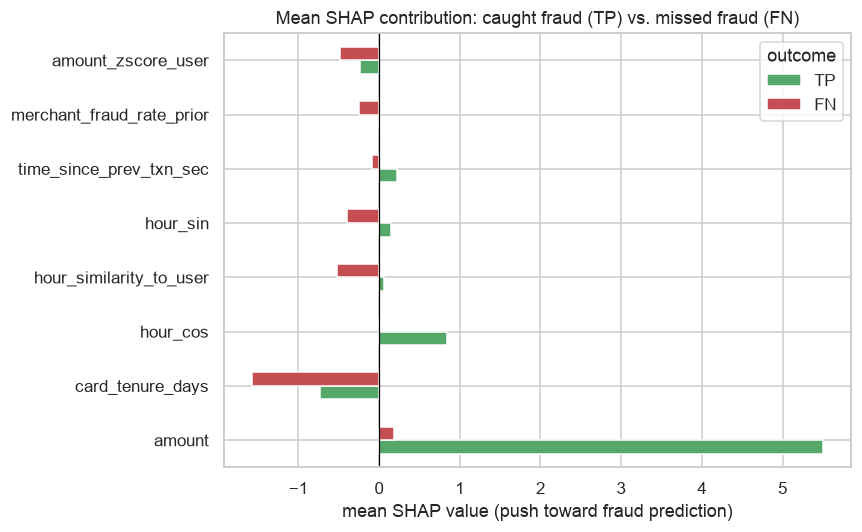

In [9]:
top_gap_features = shap_by_outcome["gap (TP - FN)"].abs().sort_values(ascending=False).head(8).index
plot_df = shap_by_outcome.loc[top_gap_features, ["TP", "FN"]]

fig, ax = plt.subplots(figsize=(8, 5))
plot_df.plot(kind="barh", ax=ax, color={"TP": "#55A868", "FN": "#C44E52"})
ax.set_xlabel("mean SHAP value (push toward fraud prediction)")
ax.set_title("Mean SHAP contribution: caught fraud (TP) vs. missed fraud (FN)")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

## Summary: the false-negative profile

In [10]:
print(f"Of {len(fn)} false negatives on validation:")
print(f"  {near_miss_fn} ({near_miss_fn / len(fn):.1%}) are near-misses (within 0.05 of threshold)")
print(f"  {confident_fn} ({confident_fn / len(fn):.1%}) are confident blind spots (0.20+ below threshold)")
print()
print("Categories contributing the most missed-fraud dollars:")
print(fn_by_category.head(5))
print()
print("Features where caught fraud (TP) gets pushed toward 'fraud' but missed fraud (FN)")
print("does not (top of the SHAP gap table above) are the model's actual blind-spot signals --")
print("missed fraud looks statistically closer to normal behavior specifically on those features.")

error_analysis_summary = {
    "n_fn": int(len(fn)),
    "n_fp": int(len(fp)),
    "fn_near_miss_pct": float(near_miss_fn / len(fn)),
    "fn_confident_blind_spot_pct": float(confident_fn / len(fn)),
    "fn_top_categories_by_dollars_missed": fn_by_category.head(5)["amount_missed"].round(2).to_dict(),
    "fp_top_categories_by_count": fp_by_category.head(5)["n_flagged"].to_dict(),
    "top_shap_gap_features": shap_by_outcome["gap (TP - FN)"].abs().sort_values(ascending=False).head(8).round(4).to_dict(),
}
os.makedirs("../reports", exist_ok=True)
with open("../reports/error_analysis.json", "w") as f:
    json.dump(error_analysis_summary, f, indent=2)
print("\nSaved ../reports/error_analysis.json")

Of 53 false negatives on validation:
  43 (81.1%) are near-misses (within 0.05 of threshold)
  3 (5.7%) are confident blind spots (0.20+ below threshold)

Categories contributing the most missed-fraud dollars:
               n_missed  amount_missed
category                              
shopping_pos          4        3554.90
misc_net              2        1566.54
entertainment         2        1080.87
misc_pos              5        1055.77
food_dining           7         810.29

Features where caught fraud (TP) gets pushed toward 'fraud' but missed fraud (FN)
does not (top of the SHAP gap table above) are the model's actual blind-spot signals --
missed fraud looks statistically closer to normal behavior specifically on those features.

Saved ../reports/error_analysis.json
